In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import sys
# Get the current working directory of the notebook
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from imputation import * 
from internal_test import *
from summary_table import *
from feature_importance_COX import *
# Show all rows
pd.set_option('display.max_rows', None)
# Show all columns
pd.set_option('display.max_columns', None)
# Do not truncate column values
pd.set_option('display.max_colwidth', None)

**2000-2006**

In [2]:
year = '2000-2006'

In [3]:
# Define input columns and target
X_columns = [
#    'hhidpn', 'NIWWAVE','demcls',
     'child', 'lbrf', 'shlt', 'ageym', 'height', 'weight', 'smokev', 'effort', 'hibpe', 'diabe', 'vgactx', 'slfmem', 'livpar', 'momage', 'dadage', 'livsib', 'hlthlm', 'hosp', 'nrshom', 'nrstim', 'nrsnit', 'doctim', 'depres', 'sleepr', 'whappy', 'flone', 'fsad', 'going', 'enlife', 'drink', 'smoken', 'cancre', 'lunge', 'hearte', 'stroke', 'arthre', 'toilta', 'adl5a', 'mapa', 'walksa', 'walk1a', 'sita', 'chaira', 'climsa', 'clim1a', 'stoopa', 'lifta', 'dimea', 'armsa', 'pusha', 'mobila', 'lgmusa', 'grossa', 'finea', 'gender', 'edstg2 8to11', 'edstg3 12', 'edstg4 13above', 'cendiv2 mid atlantic', 'cendiv3 en central', 'cendiv4 wn central', 'cendiv5 s atlantic', 'cendiv6 es central', 'cendiv7 ws central', 'cendiv8 mountain', 'cendiv9 pacific', 'cendiv11 not us or inc us terr', 'mstat2 married spouse absent', 'mstat3 partnered', 'mstat4 separated', 'mstat5 divorced', 'mstat7 widowed', 'mstat8 never married', 'raceeth1 ', 'raceeth2 ', 'raceeth3 '
]

y_column = ['time','event']

# Directories and file paths
grid_search_dir = f'../data/{year}'

In [4]:
# Define the parameter grid for COX model
param_grid = {
 'penalizer': [0.1,0.5, 1,5, 10],
 'l1_ratio': [0,0.5,1],
}

In [5]:
# ---------------- Header ----------------
print("\n" + "=" * 100)
print("Six-Year Interval — Internal Test (2000–2006)")
print("Model: Elastic Net Cox")
print("Protocol: 10-Fold Cross-Validation with 8:1:1 Train : Validation : Test splits")
print("Metrics are reported as percentages with two decimal places.")
print("=" * 100 + "\n")

n_folds = 10
imputation_methods = ['mean', 'none', 'mice']

def pct(x: float) -> str:
    """Format a fraction as a percentage with two decimals."""
    return f"{x * 100:.2f}%"

final_rows = []  # summary rows (stds only + best candidate)

for imp_method in imputation_methods:
    print(f"\nProcessing imputation method: {imp_method}")
    # ----- Step 1: Grid search using Validation AUPR across folds -----
    candidate_results = {}  # (penalizer, l1_ratio) -> list of validation AUPR

    for fold in range(1, n_folds + 1):
        train_file = os.path.join(grid_search_dir, f"2000-2006int_train_COX_{fold}.csv")
        val_file   = os.path.join(grid_search_dir, f"2000-2006int_val_COX_{fold}.csv")

        train_df = pd.read_csv(train_file)
        val_df   = pd.read_csv(val_file)
        train_df.columns = train_df.columns.astype(str)
        val_df.columns   = val_df.columns.astype(str)

        # Impute train; validation is complete-case by design
        X_train, y_train = impute_data_and_y(train_df, imp_method,X_columns,y_column)
        X_val,   y_val   = val_df[X_columns], val_df[['time','event']]

        # Build Cox training dataframe (features + time/event); drop ID/meta cols if present
        df_cox_train = pd.merge(X_train, y_train, left_index=True, right_index=True)
        for col in ['hhidpn', 'demcls', 'NIWWAVE']:
            if col in df_cox_train.columns:
                df_cox_train.drop(columns=col, inplace=True)

        X_cox_val = X_val.copy()
        for col in ['hhidpn', 'demcls', 'NIWWAVE']:
            if col in X_cox_val.columns:
                X_cox_val.drop(columns=col, inplace=True)

        # Grid search over Cox elastic-net
        for penalizer in param_grid['penalizer']:
            for l1_ratio in param_grid['l1_ratio']:
                candidate = (penalizer, l1_ratio)
                try:
                    model_cox = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
                    model_cox.fit(df_cox_train, duration_col='time', event_col='event')

                    # Convert survival to risk score at threshold_time years
                    threshold_time = 6
                    surv = model_cox.predict_survival_function(X_cox_val)
                    # Ensure threshold exists in index; if not, interpolate to nearest time
                    if threshold_time in surv.index:
                        surv_probs = surv.loc[threshold_time]
                    else:
                        # simple nearest index fallback
                        nearest_idx = (surv.index.to_series() - threshold_time).abs().idxmin()
                        surv_probs = surv.loc[nearest_idx]
                    y_scores = 1 - surv_probs.values  # higher = riskier

                    aupr = average_precision_score(y_val['event'], y_scores)
                    candidate_results.setdefault(candidate, []).append(aupr)
                except Exception:
                    continue

    if not candidate_results:
        print(f"[{imp_method}] No valid candidates found; skipping.")
        continue

    avg_val_aupr = {cand: np.mean(scores) for cand, scores in candidate_results.items()}
    best_candidate = max(avg_val_aupr, key=avg_val_aupr.get)
    best_val_aupr = avg_val_aupr[best_candidate]

    print(
        f"For imputation method '{imp_method}', best candidate: {best_candidate} "
        f"with average validation AUPR = {pct(best_val_aupr)}"
    )

    # ----- Step 2: Refit on Train+Validation and evaluate on per-fold Test -----
    penalizer_best, l1_ratio_best = best_candidate
    per_fold = []

    for fold in range(1, n_folds + 1):
        train_file = os.path.join(grid_search_dir, f"2000-2006int_train_COX_{fold}.csv")
        val_file   = os.path.join(grid_search_dir, f"2000-2006int_val_COX_{fold}.csv")
        test_file  = os.path.join(grid_search_dir, f"2000-2006int_test_COX_{fold}.csv")

        train_df = pd.read_csv(train_file)
        val_df   = pd.read_csv(val_file)
        test_df  = pd.read_csv(test_file)
        for df_ in (train_df, val_df, test_df):
            df_.columns = df_.columns.astype(str)

        # Combine train+val and impute per method
        tv_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
        X_tv, y_tv = impute_data_and_y(tv_df, imp_method,X_columns,y_column)
        df_tv = pd.merge(X_tv, y_tv, left_index=True, right_index=True)
        for col in ['hhidpn', 'demcls', 'NIWWAVE']:
            if col in df_tv.columns:
                df_tv.drop(columns=col, inplace=True)

        # Fit final model on train+val for this fold
        final_model_cox = CoxPHFitter(penalizer=penalizer_best, l1_ratio=l1_ratio_best)
        final_model_cox.fit(df_tv, duration_col='time', event_col='event')

        # Evaluate on this fold's held-out test
        X_test, y_test = test_df[X_columns], test_df[['time','event']]
        X_cox_test = X_test.copy()
        for col in ['hhidpn', 'demcls', 'NIWWAVE']:
            if col in X_cox_test.columns:
                X_cox_test.drop(columns=col, inplace=True)

        threshold_time = 6
        surv = final_model_cox.predict_survival_function(X_cox_test)
        if threshold_time in surv.index:
            surv_probs = surv.loc[threshold_time]
        else:
            nearest_idx = (surv.index.to_series() - threshold_time).abs().idxmin()
            surv_probs = surv.loc[nearest_idx]
        y_scores = 1 - surv_probs.values
        y_pred   = (y_scores >= 0.5).astype(int)  # simple threshold for ACC

        per_fold.append({
            "AUC":  roc_auc_score(y_test['event'], y_scores),
            "ACC":  accuracy_score(y_test['event'], y_pred),
            "AUPR": average_precision_score(y_test['event'], y_scores),
        })

    # Means and stds across folds
    aucs  = np.array([m["AUC"]  for m in per_fold])
    accs  = np.array([m["ACC"]  for m in per_fold])
    auprs = np.array([m["AUPR"] for m in per_fold])

    mean_auc,  std_auc  = aucs.mean(),  aucs.std()
    mean_acc,  std_acc  = accs.mean(),  accs.std()
    mean_aupr, std_aupr = auprs.mean(), auprs.std()

    print(
        f"Final test metrics for imputation method '{imp_method}': "
        f"AUC = {pct(mean_auc)}, ACC = {pct(mean_acc)}, AUPR = {pct(mean_aupr)}"
    )
    print(
        f"Standard deviations across folds (for error bars): "
        f"AUC_std = {pct(std_auc)}, ACC_std = {pct(std_acc)}, AUPR_std = {pct(std_aupr)}"
    )

    # Keep only stds + best candidate in summary
    final_rows.append({
        "Imputation": imp_method,
        "BestCandidate": best_candidate,
        "AUC_std":  std_auc,
        "ACC_std":  std_acc,
        "AUPR_std": std_aupr,
    })

# ----- Summary table (stds only) -----
if final_rows:
    df_sum = pd.DataFrame(final_rows)
    cols = ["Imputation", "BestCandidate", "AUC_std", "ACC_std", "AUPR_std"]
    print("\n" + "=" * 100)
    print("Internal Cross-Validation — Elastic Net Cox Standard Deviations Summary (for error bars)")
    print("=" * 100)
    display_df = df_sum.copy()
    for c in ["AUC_std", "ACC_std", "AUPR_std"]:
        display_df[c] = display_df[c].apply(pct)
    print(display_df[cols].to_string(index=False))


Six-Year Interval — Internal Test (2000–2006)
Model: Elastic Net Cox
Protocol: 10-Fold Cross-Validation with 8:1:1 Train : Validation : Test splits
Metrics are reported as percentages with two decimal places.


Processing imputation method: mean
For imputation method 'mean', best candidate: (0.1, 0) with average validation AUPR = 18.25%
Final test metrics for imputation method 'mean': AUC = 81.61%, ACC = 96.39%, AUPR = 17.83%
Standard deviations across folds (for error bars): AUC_std = 2.88%, ACC_std = 0.31%, AUPR_std = 4.67%

Processing imputation method: none
For imputation method 'none', best candidate: (0.1, 0) with average validation AUPR = 17.48%
Final test metrics for imputation method 'none': AUC = 81.82%, ACC = 96.48%, AUPR = 16.77%
Standard deviations across folds (for error bars): AUC_std = 2.93%, ACC_std = 0.30%, AUPR_std = 3.81%

Processing imputation method: mice
For imputation method 'mice', best candidate: (0.1, 0) with average validation AUPR = 18.29%
Final test metri

#### Internal Test with stratified data splitting via miceforest imputation

In [5]:
train_val_cox  = pd.read_csv('../data/2000-2006/2000-2006internal_trainval_COX.csv')
test_cox = pd.read_csv('../data/2000-2006/2000-2006internal_test_COX.csv')

In [6]:
df_full = pd.concat([train_val_cox, test_cox], axis=0, ignore_index=True)
X_full, y_full = impute_data_and_y(df_full, 'mice',X_columns,y_column)

In [8]:
train_sets = []
train_val_sets = []
val_sets = []
test_sets = []
for i in range(10):
    # make train+val and test data split 8:2
    X_train_val, X_test, y_train_val, y_test = train_test_split(X_full, y_full, test_size=0.2, stratify=y_full, random_state=i)
    train_val_sets.append((X_train_val, y_train_val))
    test_sets.append((X_test, y_test))
    # make train and val data split 6:2. finally train:val:test = 6:2:2
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=i)
    train_sets.append((X_train, y_train))
    val_sets.append((X_val, y_val))

In [9]:
#grid search
candidate_results = {}
for train, val in zip(train_sets,val_sets):
    X_train, y_train = train
    X_val, y_val = val
    combinations = itertools.product(*param_grid.values())
    for parameter in combinations:
        candidate = list(param_grid.keys())
        try:
            model_cox = CoxPHFitter(**dict(zip(candidate, parameter)))
            model_cox.fit(pd.concat([X_train, y_train], axis=1), duration_col='time', event_col='event')
            # Convert survival to risk score at threshold_time years
            threshold_time = 6
            surv = model_cox.predict_survival_function(X_val)
            # Ensure threshold exists in index; if not, interpolate to nearest time
            if threshold_time in surv.index:
                surv_probs = surv.loc[threshold_time]
            else:
                # simple nearest index fallback
                nearest_idx = (surv.index.to_series() - threshold_time).abs().idxmin()
                surv_probs = surv.loc[nearest_idx]
            y_scores = 1 - surv_probs.values  # higher = riskier

            aupr = average_precision_score(y_val['event'], y_scores)
            candidate_results.setdefault(parameter, []).append(aupr)
        except Exception:
            continue
avg_val_aupr = {cand: np.mean(scores) for cand, scores in candidate_results.items()}
best_candidate = max(avg_val_aupr, key=avg_val_aupr.get)
best_val_aupr = avg_val_aupr[best_candidate]
print(
    f"For imputation method 'mice', best candidate: {best_candidate} "
    f"with average validation AUPR = {pct(best_val_aupr)}"
        )

For imputation method 'mice', best candidate: (0.1, 0) with average validation AUPR = 26.67%


In [10]:
per_fold = []
optimal_thresholds_list = []

# Step 1: Find optimal threshold for each fold
for train_val, test in zip(train_val_sets, test_sets):
    X_train_val, y_train_val = train_val
    X_test, y_test = test
    final_model = CoxPHFitter(**dict(zip(candidate, best_candidate)))
    final_model.fit(pd.concat([X_train_val, y_train_val], axis=1), duration_col='time', event_col='event')
    threshold_time = 6
    surv = final_model.predict_survival_function(X_test)
    if threshold_time in surv.index:
        surv_probs = surv.loc[threshold_time]
    else:
        nearest_idx = (surv.index.to_series() - threshold_time).abs().idxmin()
        surv_probs = surv.loc[nearest_idx]
    y_scores = 1 - surv_probs.values
    
    # Find optimal threshold based on F1 score
    precision, recall, thresholds = precision_recall_curve(y_test['event'], y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
    
    optimal_thresholds_list.append(optimal_threshold)

# Step 2: Use mean optimal threshold for all folds
mean_optimal_threshold = np.mean(optimal_thresholds_list)
print(f"Mean Optimal Threshold: {mean_optimal_threshold:.4f}")
print(f"Optimal thresholds per fold: {[f'{t:.4f}' for t in optimal_thresholds_list]}")

# Step 3: Calculate metrics using optimal threshold
per_fold = []
for train_val, test in zip(train_val_sets, test_sets):
    X_train_val, y_train_val = train_val
    X_test, y_test = test
    final_model = CoxPHFitter(**dict(zip(candidate, best_candidate)))
    final_model.fit(pd.concat([X_train_val, y_train_val], axis=1), duration_col='time', event_col='event')
    threshold_time = 6
    surv = final_model.predict_survival_function(X_test)
    if threshold_time in surv.index:
        surv_probs = surv.loc[threshold_time]
    else:
        nearest_idx = (surv.index.to_series() - threshold_time).abs().idxmin()
        surv_probs = surv.loc[nearest_idx]
    y_scores = 1 - surv_probs.values
    y_pred = (y_scores >= mean_optimal_threshold).astype(int)
    
    per_fold.append({
        "AUC": roc_auc_score(y_test['event'], y_scores),
        "ACC": accuracy_score(y_test['event'], y_pred),
        "AUPR": average_precision_score(y_test['event'], y_scores),
        "Precision": precision_score(y_test['event'], y_pred),
        "Recall": recall_score(y_test['event'], y_pred),
        "F1": f1_score(y_test['event'], y_pred),
    })

# Step 4: Calculate means and stds across folds
aucs      = np.array([m["AUC"]       for m in per_fold])
accs      = np.array([m["ACC"]       for m in per_fold])
auprs     = np.array([m["AUPR"]      for m in per_fold])
precisions = np.array([m["Precision"] for m in per_fold])
recalls   = np.array([m["Recall"]    for m in per_fold])
f1s       = np.array([m["F1"]        for m in per_fold])

mean_auc,  std_auc  = aucs.mean(),  aucs.std()
mean_acc,  std_acc  = accs.mean(),  accs.std()
mean_aupr, std_aupr = auprs.mean(), auprs.std()
mean_precision, std_precision = precisions.mean(), precisions.std()
mean_recall,    std_recall    = recalls.mean(),    recalls.std()
mean_f1,        std_f1        = f1s.mean(),        f1s.std()

print("\nCoxPHFitter with MICE Imputation — Internal Test")
print(f"Optimal Threshold Used: {mean_optimal_threshold:.4f}")
print(
    f"Final test metrics: "
    f"AUC = {pct(mean_auc)}, ACC = {pct(mean_acc)}, AUPR = {pct(mean_aupr)}, "
    f"Precision = {pct(mean_precision)}, Recall = {pct(mean_recall)}, F1 = {pct(mean_f1)}"
)
print(
    f"Standard deviations across folds: "
    f"AUC_std = {pct(std_auc)}, ACC_std = {pct(std_acc)}, AUPR_std = {pct(std_aupr)}, "
    f"Precision_std = {pct(std_precision)}, Recall_std = {pct(std_recall)}, F1_std = {pct(std_f1)}"
)

Mean Optimal Threshold: 0.1982
Optimal thresholds per fold: ['0.1998', '0.1643', '0.1958', '0.2069', '0.1766', '0.2324', '0.2019', '0.2001', '0.1588', '0.2451']

CoxPHFitter with MICE Imputation — Internal Test
Optimal Threshold Used: 0.1982
Final test metrics: AUC = 79.36%, ACC = 83.89%, AUPR = 25.68%, Precision = 27.62%, Recall = 46.33%, F1 = 34.60%
Standard deviations across folds: AUC_std = 0.97%, ACC_std = 0.45%, AUPR_std = 1.04%, Precision_std = 1.15%, Recall_std = 2.06%, F1_std = 1.38%


ageym             0.041
mapa              0.026
slfmem            0.019
mstat7 widowed    0.016
edstg3 12         0.015
dtype: float64

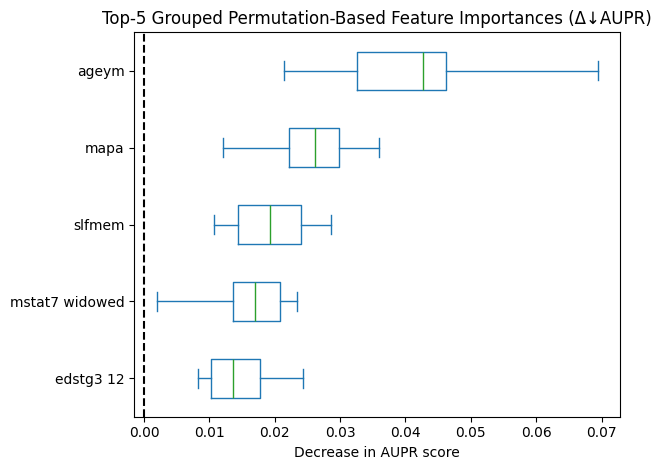

In [6]:
X_train, y_train = impute_data_and_y(train_val_cox, 'mice', X_columns, y_column=['time','event'])
X_test, y_test = test_cox[X_columns], test_cox[['time','event']]
cox = CoxPHFitter(penalizer=0.1, l1_ratio=0)
cox.fit(pd.concat([X_train,y_train],axis=1), duration_col='time', event_col='event')
top_5 = feature_importance_cox(cox, X_test, y_test, n_repeats=10)
top_5